# 07 — Feature: GPU
Parses the `Gpu` string into brand and applies target encoding.

**Output features:** `GPU_Brand_TE`, `GPU_TE`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce

In [2]:
ld = pd.read_csv("laptop_data_features.csv")
print(f"Shape: {ld.shape}")

Shape: (1303, 35)


In [3]:
# Explore Gpu
print(ld['Gpu'].value_counts().head(15))
print(f"\nUnique GPUs: {ld['Gpu'].nunique()}")

Gpu
Intel HD Graphics 620         281
Intel HD Graphics 520         185
Intel UHD Graphics 620         68
Nvidia GeForce GTX 1050        66
Nvidia GeForce GTX 1060        48
Nvidia GeForce 940MX           43
AMD Radeon 530                 41
Intel HD Graphics 500          39
Intel HD Graphics 400          37
Nvidia GeForce GTX 1070        30
Intel HD Graphics              29
Nvidia GeForce GTX 1050 Ti     28
AMD Radeon R5 M430             22
Nvidia GeForce 930MX           20
AMD Radeon 520                 17
Name: count, dtype: int64

Unique GPUs: 110


In [4]:
# Extract GPU Brand (first word)
ld['GPU_Brand'] = ld['Gpu'].str.extract(r'^(\w+)')
print("GPU Brand distribution:")
print(ld['GPU_Brand'].value_counts())

GPU Brand distribution:
GPU_Brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64


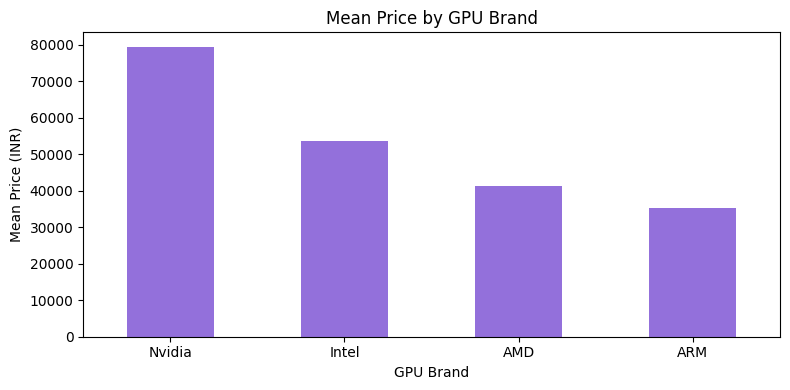

In [5]:
# Mean price by GPU brand
plt.figure(figsize=(8, 4))
brand_mean = ld.groupby('GPU_Brand')['Price'].mean().sort_values(ascending=False)
brand_mean.plot(kind='bar', color='mediumpurple')
plt.title("Mean Price by GPU Brand")
plt.xlabel("GPU Brand")
plt.ylabel("Mean Price (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# Target encode GPU Brand
brand_mean = ld.groupby('GPU_Brand')['Price'].mean()
ld['GPU_Brand_TE'] = ld['GPU_Brand'].map(brand_mean)

In [7]:
# Target encode full GPU string (captures model-level detail)
encoder = ce.TargetEncoder(cols=['Gpu'])
ld['GPU_TE'] = encoder.fit_transform(ld[['Gpu']], ld['Price'])

In [8]:
# Correlation with Price
gpu_cols = ['GPU_Brand_TE', 'GPU_TE']
print("Correlation with Price:")
print(ld[gpu_cols + ['Price']].corr()['Price'].sort_values(ascending=False))

Correlation with Price:
Price           1.000000
GPU_TE          0.649540
GPU_Brand_TE    0.366134
Name: Price, dtype: float64


In [9]:
# Drop raw and intermediate columns
ld.drop(columns=['Gpu', 'GPU_Brand'], inplace=True)

In [10]:
ld.to_csv("laptop_data_features.csv", index=False)
print("Saved: laptop_data_features.csv")
print(f"Shape: {ld.shape}")
print(f"Columns: {list(ld.columns)}")

Saved: laptop_data_features.csv
Shape: (1303, 36)
Columns: ['Inches', 'Ram', 'OpSys', 'Weight', 'Price', 'Company_TE', 'Type_2 in 1 Convertible', 'Type_Gaming', 'Type_Netbook', 'Type_Notebook', 'Type_Ultrabook', 'Type_Workstation', 'Screen_Width', 'Screen_Height', 'Screen_PPI', 'Screen_IsTouchscreen', 'Screen_IsIPS', 'Screen_IsRetina', 'Screen_IsFullHD', 'Screen_Is4K', 'CPU_GHz', 'CPU_Brand_TE', 'CPU_Family_TE', 'CPU_TE', 'Mem_SSD_GB', 'Mem_HDD_GB', 'Mem_Flash_GB', 'Mem_eMMC_GB', 'Mem_Total_GB', 'Mem_HasSSD', 'Mem_IsCombo', 'Mem_IsSingleStorage', 'Mem_IsHybridStorage', 'Mem_PrimaryType_TE', 'GPU_Brand_TE', 'GPU_TE']
